# Problem Statement:-
Imagine a Telecom company wants to know which customer likely to leave and which want to stay so they can offer better plans , discount etc., to         those coustomer who are most likely to leave so it will eventually help the Company business.

In [260]:
# 1. Problem Statement - Done
# 2. Import Libraries - Done
# 3. Load Dataset - Done
# 4. Data Understanding - Done
# 5. Exploratory Data Analysis - Done
# 6. Data Preprocessing - Done
# 7. Feature Engineering - Done
# 8. Train-Test Split - Done
# 9. Feature Scaling - Done
# 10. Class Imbalance - Done
# 11. Logistic Regression From Scratch - Done
# 12. Model Evaluation - Done
# 13. Scikit-Learn Model - Done
# 14. Model Comparison - Done
# 15. Business Insights - Done
# 16. Conclusion - Done

# Import Libraries:-

In [261]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset:-

In [262]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# EDA:-

In [263]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [264]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [265]:
# Shape:-
df.shape

(7043, 21)

In [266]:
# All Columns:-
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [268]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [269]:
# Target Column Distribution:-
ch_dist = df['Churn'].value_counts()
ch_dist

,count
Churn,
No,5174
Yes,1869


In [270]:
# Probability:-
print(f"Churn No :{round((ch_dist[0] * 100 / 7043),2)}%")
print(f"Churn Yes : {round((ch_dist[1] * 100 / 7043),2)}%")

Churn No :73.46%
Churn Yes : 26.54%


/tmp/ipykernel_3796/1226052832.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Churn No :{round((ch_dist[0] * 100 / 7043),2)}%")
/tmp/ipykernel_3796/1226052832.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Churn Yes : {round((ch_dist[1] * 100 / 7043),2)}%")


In [271]:
# In Above Code we can see Class Imbalance.

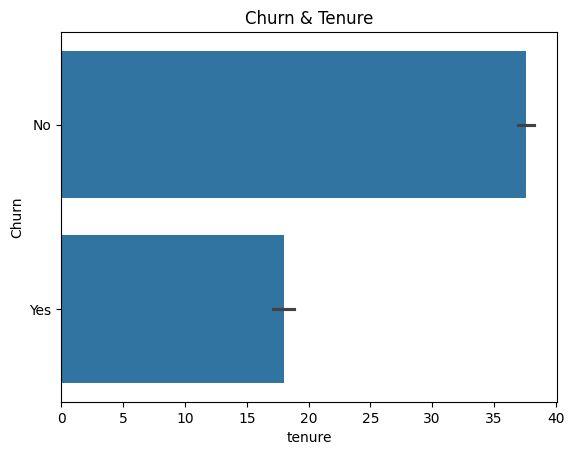

In [272]:
sns.barplot(x='tenure',y='Churn',data=df)
plt.title("Churn & Tenure")
plt.show()

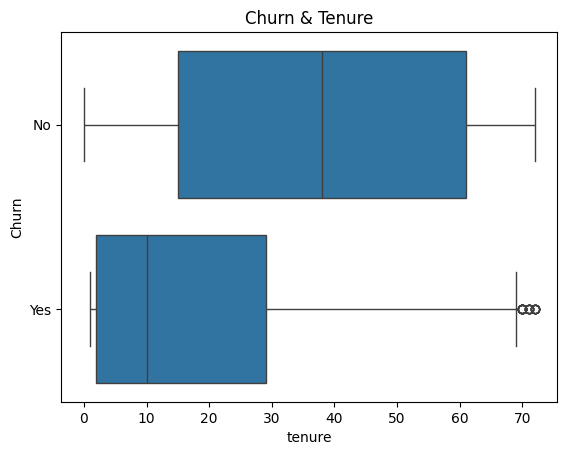

In [273]:
sns.boxplot(x='tenure',y='Churn',data=df)
plt.title("Churn & Tenure")
plt.show()

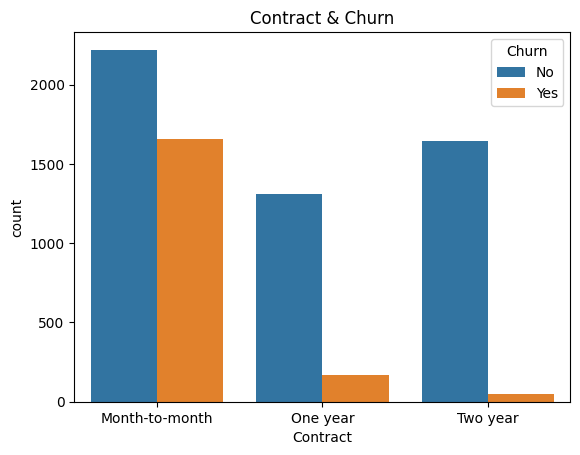

In [274]:
sns.countplot(data=df,x='Contract',hue='Churn')
plt.title('Contract & Churn')
plt.show()


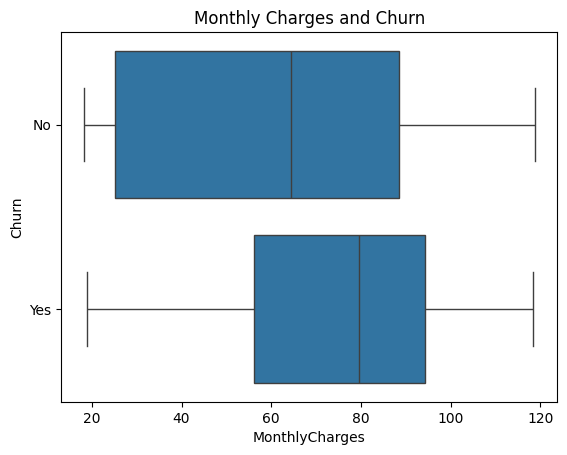

In [275]:
sns.boxplot(x=df['MonthlyCharges'],y=df['Churn'])
plt.title('Monthly Charges and Churn')
plt.show()

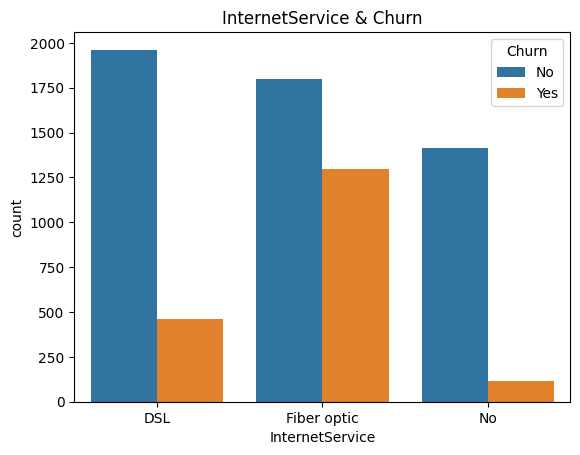

In [276]:
sns.countplot(data=df,x=df['InternetService'],hue=df['Churn'])
plt.title('InternetService & Churn')
plt.show()

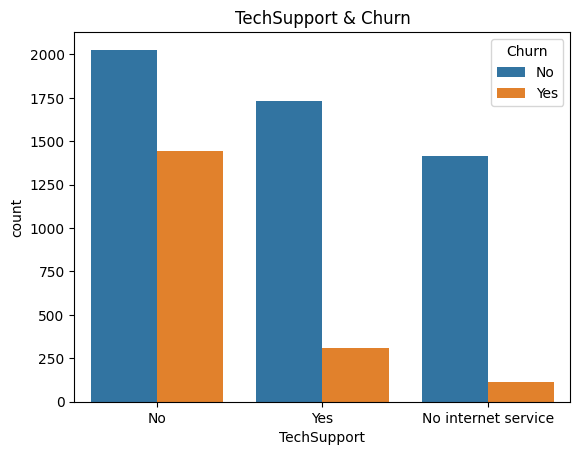

In [277]:
sns.countplot(x=df['TechSupport'],hue=df['Churn'])
plt.title('TechSupport & Churn')
plt.show()

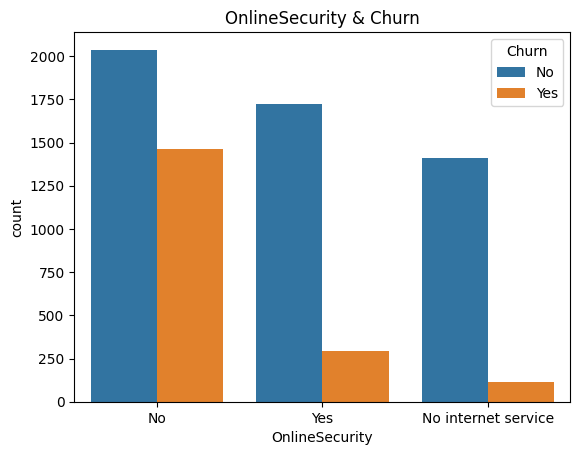

In [278]:
sns.countplot(x=df['OnlineSecurity'],hue=df['Churn'])
plt.title('OnlineSecurity & Churn')
plt.show()

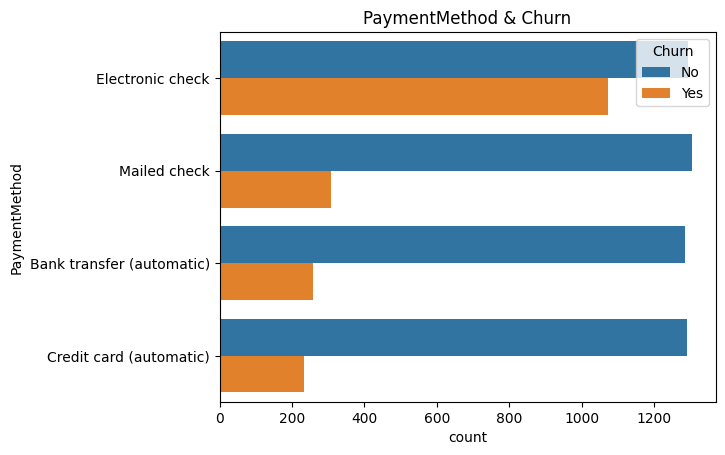

In [279]:
sns.countplot(y=df['PaymentMethod'],hue=df['Churn'])
plt.title('PaymentMethod & Churn')
plt.show()

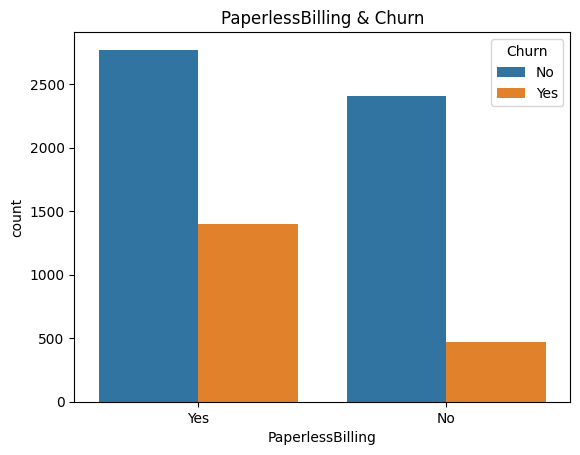

In [280]:
sns.countplot(x=df['PaperlessBilling'],hue=df['Churn'])
plt.title('PaperlessBilling & Churn')
plt.show()

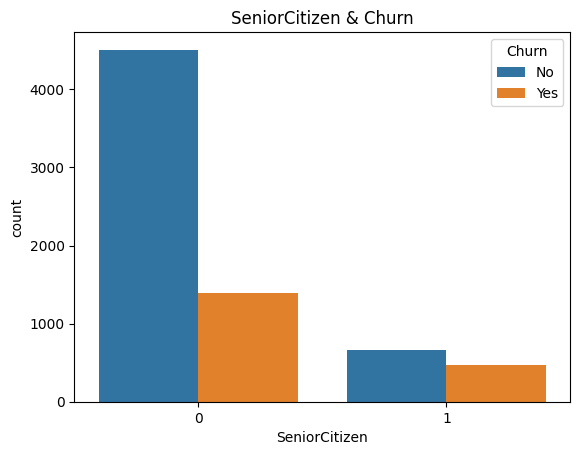

In [281]:
sns.countplot(x=df['SeniorCitizen'],hue=df['Churn'])
plt.title('SeniorCitizen & Churn')
plt.show()

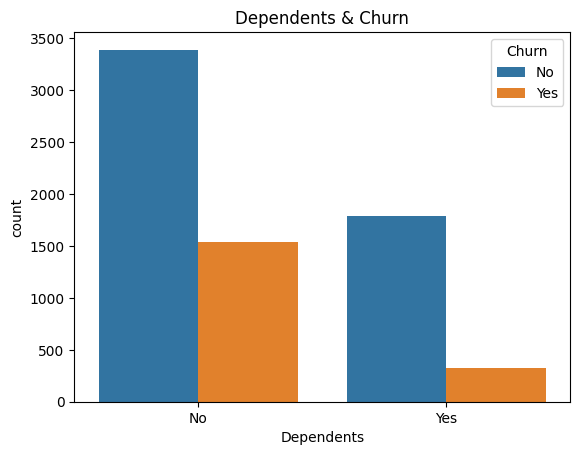

In [282]:
sns.countplot(x=df['Dependents'],hue=df['Churn'])
plt.title('Dependents & Churn')
plt.show()

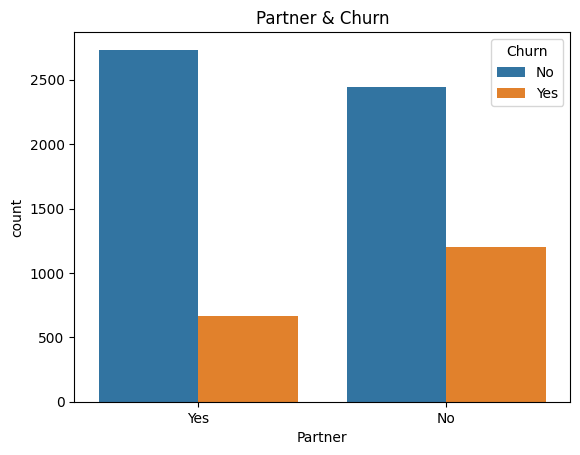

In [283]:
sns.countplot(x=df['Partner'],hue=df['Churn'])
plt.title('Partner & Churn')
plt.show()

In [284]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [285]:
pd.crosstab(df['InternetService'],df['Churn'],normalize='index')

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [286]:
pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


In [287]:
pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


In [288]:
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [289]:
pd.crosstab(df['PaperlessBilling'],df['Churn'],normalize='index')

Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


In [290]:
pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize='index')

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [291]:
pd.crosstab(df['Dependents'],df['Churn'],normalize='index')

Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.845498,0.154502


In [292]:
pd.crosstab(df['Partner'],df['Churn'],normalize='index')

Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


In [293]:
# Observations:-
# 1. Month to Month Customers mostly leave as u can see above results like approx 42%.
# 2. Mostly Fiber Optic Internet Service User Leave mostly with 41%.
# 3. Customers without TechSupport have a higher churn rate.
# 4. Mostly User Churn Due to No OnlineSecurity.
# 5. Electronic check has the highest churn rate, around 45%.
# 6. So Customers using PaperlessBilling have the higher Churn rate
# 7. Senior citizens actually have a much higher churn rate 41% than non-senior customers 23%.
# 8. 31% Churn Occurs without Dependents.
# 9. Customers without partners have a higher churn rate than customers with partners.
# 10. Customers who churn tend to have higher MonthlyCharges than customers who stay.

In [294]:
## Missing Values:-
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [295]:
# Duplicated Vallues:-
df.duplicated().sum()

np.int64(0)

In [296]:
Converted_Total = pd.to_numeric(df['TotalCharges'],errors='coerce')
Converted_Total.isna().sum()

np.int64(11)

In [297]:
Converted_Total.isnull()

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [298]:
df[Converted_Total.isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [299]:
# Data Filling
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [300]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [301]:
# Data Cleaning
df.drop('customerID',axis=1,inplace=True)

In [302]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [303]:
cat_col = df.select_dtypes(include='object').columns
print(cat_col)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [304]:
for col in cat_col:
  print(f"Column : {col} : {df[col].nunique()}")

Column : gender : 2
Column : Partner : 2
Column : Dependents : 2
Column : PhoneService : 2
Column : MultipleLines : 3
Column : InternetService : 3
Column : OnlineSecurity : 3
Column : OnlineBackup : 3
Column : DeviceProtection : 3
Column : TechSupport : 3
Column : StreamingTV : 3
Column : StreamingMovies : 3
Column : Contract : 3
Column : PaperlessBilling : 2
Column : PaymentMethod : 4
Column : Churn : 2


In [305]:
for col in cat_col:
  print(df[col].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
StreamingTV
No                     2810
Y

# Data Preprocessing

# Encoding

In [306]:
df['gender'] = df['gender'].map({'Male':0,'Female':1})

In [307]:
l = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

In [308]:
choice = {'Yes':1,'No':0}

In [309]:
for col in l:
  df[col] = df[col].map(choice)

In [310]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


# Feature Engineering

In [311]:
service_col = ['PhoneService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df['Total_Services'] = (df[service_col] == 'Yes').sum(axis=1)

# Encoding

In [312]:
df = pd.get_dummies(df,columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
'Contract','PaymentMethod'],drop_first=True,dtype=int)

In [313]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [314]:
df.shape

(7043, 32)

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  Total_Services                         7043 non-null   int64  
 11  Mult

In [316]:
# Split X and y:
X = df.drop('Churn',axis=1)
y = df['Churn']

# Train Test Split

In [317]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Feature Scaling

In [318]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [319]:
X_train_Scaled = scaler.fit_transform(X_train)
X_train_Scaled

array([[-0.99433624, -0.44177295, -0.96923413, ..., -0.52380561,
         1.40690298, -0.54384572],
       [-0.99433624, -0.44177295,  1.03174245, ..., -0.52380561,
        -0.71078107,  1.83875676],
       [-0.99433624, -0.44177295,  1.03174245, ..., -0.52380561,
        -0.71078107,  1.83875676],
       ...,
       [ 1.00569602,  2.2636062 , -0.96923413, ..., -0.52380561,
        -0.71078107,  1.83875676],
       [ 1.00569602, -0.44177295,  1.03174245, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [-0.99433624, -0.44177295, -0.96923413, ..., -0.52380561,
        -0.71078107,  1.83875676]])

In [320]:
X_test_Scaled = scaler.transform(X_test)
X_test_Scaled

array([[-0.99433624, -0.44177295,  1.03174245, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [ 1.00569602,  2.2636062 , -0.96923413, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [ 1.00569602, -0.44177295,  1.03174245, ...,  1.90910518,
        -0.71078107, -0.54384572],
       ...,
       [-0.99433624, -0.44177295, -0.96923413, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [ 1.00569602, -0.44177295, -0.96923413, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [ 1.00569602, -0.44177295,  1.03174245, ..., -0.52380561,
        -0.71078107, -0.54384572]])

# Class Imbalance

In [321]:
y_train.value_counts()

,count
Churn,
0,4139
1,1495


In [322]:
# m  → Total number of training samples
# n0 → Number of Churn = 0
# n1 → Number of Churn = 1

In [323]:
m = y_train.count()
n0 = y_train.value_counts()[0]
n1 = y_train.value_counts()[1]
print(f"m:{m} | n0:{n0} | n1:{n1}")

m:5634 | n0:4139 | n1:1495


In [324]:
w0 = (m/(2*n0))
w1 = (m/(2*n1))
print(f"w0:{round(w0,2)} & w1:{round(w1,2)}")

w0:0.68 & w1:1.88


In [325]:
# These are the Penalty that should be multiplied by error(Acc. to Churn).

# Sigmoid Function

In [326]:
def sigmoid(z):
  return ( 1 / (1 + np.exp(-z)))

In [327]:
X_train_Scaled.shape

(5634, 31)

In [328]:
weight = np.zeros(X_train_Scaled.shape[1])
bias = 0
print(f"Weight:{weight} & Bias:{bias}")

Weight:[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0.] & Bias:0


In [329]:
sample_weight = np.where(y_train == 1 , w1 , w0)
sample_weight

array([0.68059918, 0.68059918, 0.68059918, ..., 1.88428094, 0.68059918,
       0.68059918])

In [330]:
l_r = 0.1

In [331]:
iterations = 2000
losses = []

for i in range(iterations):
  # Implementing Linear part of Logistic Regression:-
  # z = Xw + b
  # @  = Matrix Multiplication
  z = (X_train_Scaled @ weight + bias)

  # Passing z Through sigmoid Function:-
  prediction = sigmoid(z)

  # something to restrict prediction b/w a very tiny value:-
  prediction_clipped = np.clip(prediction , 1e-15 , 1 - 1e-15)

  # Calculate Churn loss and Non Churn Loss:-
  churn_loss = y_train * np.log(prediction_clipped)
  non_churn_loss = (1 - y_train) * np.log(1 - prediction_clipped)

  weighted_loss = sample_weight * (churn_loss + non_churn_loss)

  loss = -np.mean(weighted_loss)

  # Store loss
  losses.append(loss)

  weighted_error = sample_weight * (prediction - y_train)

  dw = (X_train_Scaled.T @ weighted_error) / m

  db = np.mean(weighted_error)

  # Update Weight and Bias:-
  weight = weight - l_r * dw
  bias = bias - l_r * db

In [332]:
print(f"Losses[0]:{losses[0]} & Losses[-1]:{losses[-1]}")

Losses[0]:0.6931471805599454 & Losses[-1]:0.4819964811533907


In [333]:
z_test = X_test_Scaled @ weight + bias

In [334]:
test_probability = sigmoid(z_test)
test_probability

array([0.09785503, 0.85853614, 0.1593764 , ..., 0.32700565, 0.0179611 ,
       0.01934727])

In [335]:
y_pred = (test_probability >= 0.5).astype(int)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

# Model Evaluation:-

In [336]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score , confusion_matrix

In [338]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test , y_pred)
recall = recall_score(y_test , y_pred)
f1 = f1_score(y_test , y_pred)
ras = roc_auc_score(y_test , test_probability)
print(f"Accuracy : {accuracy}")
print(f"Precision : {precision}")
print(f"Recall : {recall}")
print(f"F1 : {f1}")
print(f"ROC AUC Score : {ras}")

Accuracy : 0.7409510290986515
Precision : 0.5077989601386482
Recall : 0.7834224598930482
F1 : 0.6161934805467929
ROC AUC Score : 0.8400578676793511


In [339]:
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion : {cm}")

Confusion : [[751 284]
 [ 81 293]]


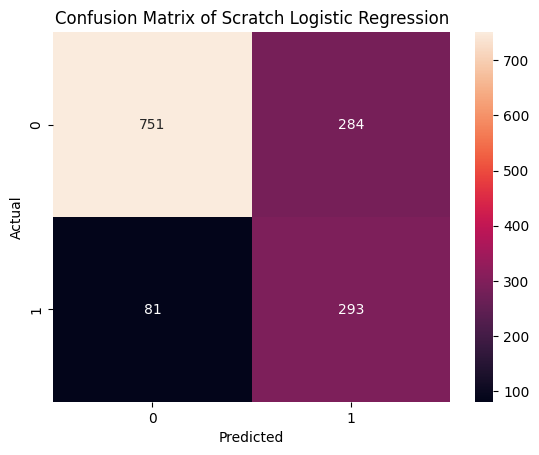

In [340]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Scratch Logistic Regression')
plt.show()

# Logistic Regression:-

In [341]:
class_weight = 'balanced'

In [342]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced',max_iter=2000,random_state=42)

In [343]:
model.fit(X_train_Scaled , y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [344]:
pred = model.predict(X_test_Scaled)

In [345]:
probability = model.predict_proba(X_test_Scaled)[:,1]
probability

array([0.11873243, 0.85168428, 0.1410103 , ..., 0.33533522, 0.01296716,
       0.01746061])

In [346]:
laccuracy = accuracy_score(y_test , pred)
lprecision = precision_score(y_test , pred)
lrecall = recall_score(y_test , pred)
lf1 = f1_score(y_test , pred)
lras = roc_auc_score(y_test , probability)
print(f"Accuracy : {laccuracy}")
print(f"Precision : {lprecision}")
print(f"Recall : {lrecall}")
print(f"F1 : {lf1}")
print(f"ROC AUC Score : {lras}")

Accuracy : 0.7388218594748048
Precision : 0.5051724137931034
Recall : 0.7834224598930482
F1 : 0.6142557651991615
ROC AUC Score : 0.841463225606448


# Model Comparison:-

## Scratch Logisitic Regression V/s Scikit Logistic Regression

In [347]:
comparison = pd.DataFrame({'Metrics':['Accuracy','Precision','Recall','F1 Score','ROC AUC Score'],
                    'Scratch Logistic Regression':[0.7409510290986515,0.5077989601386482,0.7834224598930482,0.6161934805467929,0.8400578676793511],
                    'Scikit Logistic Regression':[0.7388218594748048,0.5051724137931034,0.7834224598930482,0.6142557651991615,0.841463225606448]})

In [348]:
comparison

,Metrics,Scratch Logistic Regression,Scikit Logistic Regression
0,Accuracy,0.740951,0.738822
1,Precision,0.507799,0.505172
2,Recall,0.783422,0.783422
3,F1 Score,0.616193,0.614256
4,ROC AUC Score,0.840058,0.841463


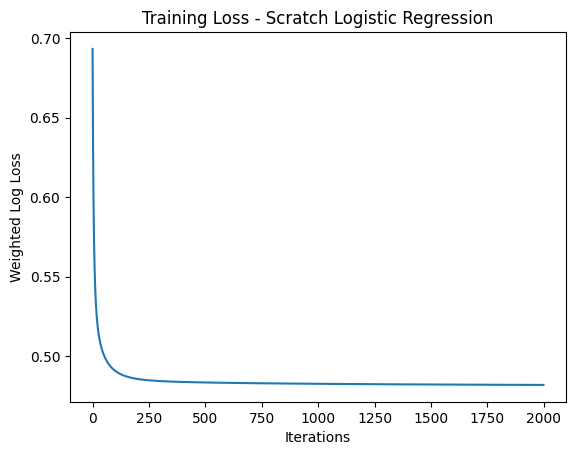

In [349]:
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Weighted Log Loss")
plt.title("Training Loss - Scratch Logistic Regression")
plt.show()

## Business Insights

The analysis identified several customer characteristics that are strongly associated with churn:

- Customers with month-to-month contracts showed significantly higher churn compared to customers with one-year or two-year contracts.
- Customers with shorter tenure were more likely to churn, indicating that new customers are particularly vulnerable.
- Fiber optic internet customers showed a relatively high churn rate.
- Customers without Tech Support and Online Security had higher churn rates.
- Customers using electronic check as their payment method showed the highest churn among payment methods.
- Customers with higher monthly charges tended to have a greater likelihood of churn.
- Senior citizens showed a higher churn rate compared to non-senior customers.

### Business Recommendations

- Provide special retention offers to high-risk and newly joined customers.
- Encourage month-to-month customers to move to longer-term contracts through discounts or incentives.
- Investigate customer experience and pricing concerns among fiber optic users.
- Promote Tech Support and Online Security services to customers who do not currently use them.
- Target customers predicted as high-risk by the churn model with personalized retention campaigns.

## Conclusion

In this project, a Logistic Regression classifier was successfully implemented from scratch using NumPy to predict customer churn.

The complete machine learning pipeline included exploratory data analysis, data cleaning, feature engineering, categorical encoding, feature scaling, class imbalance handling, model implementation, training, and evaluation.

The custom Logistic Regression model achieved approximately 74.10% accuracy, 78.34% recall, 61.62% F1 score, and a ROC-AUC score of 0.8401.

The model was benchmarked against Scikit-Learn Logistic Regression, which produced very similar results. This indicates that the custom implementation successfully reproduced the fundamental behavior of Logistic Regression.

The relatively high recall is particularly useful for churn prediction because it allows the model to identify a large proportion of customers who are actually at risk of leaving. These predictions can help businesses prioritize retention strategies for high-risk customers.